In [2]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.animation import FuncAnimation

df = pd.read_json('/Users/kurozuhajime/Desktop/Pythonコード・データ/気象データ解析/気象データ/World/era5_world_t2_day.json')
source = df['data_source'].iloc[0]

def leap(year):
    if year % 100 == 0 and year % 400 != 0:
        return False
    elif year % 4 == 0:
        return True
    else:
        return False

"""
def get_month_day(j, k, CAL):
    if 0 <= j < CAL[0]:
        mm = 1
        c[0] += 1
        dy.append(c[0])
    elif CAL[k-1] <= j < CAL[k]:
        mm = k + 1
        c[k] += 1
        dy.append(c[k])
    return (mm, dy)
"""

    
cal_lp = [31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
cal = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]

lp_l = []
sum = 0
for i in range(len(cal_lp)):
    sum += cal_lp[i]
    lp_l.append(sum) 

nlp_l = []
sum = 0
for i in range(len(cal)):
    sum += cal[i]
    nlp_l.append(sum)

#print(nlp_l)
#print(lp_l)




yr = []
mth = []
dy = []
#print(d)
temp = []
for i in range(len(df)-3):
    m = 1
    c = [0]*12
    y = int(df['name'][i])
    CAL = lp_l
    if not leap(y):
        CAL = nlp_l
    #print(CAL)
    for j in range(366):
        if df['data'][i][j] is None:
            #print('======')
            continue
        yr.append(y)
        
        #print(CAL[m-1])

        #x = get_month_day(j, m, CAL)

        if 0 <= j < CAL[0]:
            m = 1
            c[0] += 1
            dy.append(c[0])  
        elif CAL[0] <= j < CAL[1]:
            m = 2
            c[1]+=1
            dy.append(c[1])  
        elif CAL[1] <= j < CAL[2]:
            m = 3
            c[2]+=1
            dy.append(c[2])  
        elif CAL[2] <= j < CAL[3]:
            m = 4
            c[3]+=1
            dy.append(c[3])
        elif CAL[3] <= j < CAL[4]:
            m = 5
            c[4]+=1
            dy.append(c[4])
        elif CAL[4] <= j < CAL[5]:
            m = 6
            c[5]+=1
            dy.append(c[5])
        elif CAL[5] <= j < CAL[6]:
            m = 7
            c[6]+=1
            dy.append(c[6])
        elif CAL[6] <= j < CAL[7]:
            m = 8
            c[7]+=1
            dy.append(c[7])
        elif CAL[7] <= j < CAL[8]:
            m = 9
            c[8]+=1
            dy.append(c[8])
        elif CAL[8] <= j < CAL[9]:
            m = 10
            c[9]+=1
            dy.append(c[9])
        elif CAL[9] <= j < CAL[10]:
            m = 11
            c[10]+=1
            dy.append(c[10])
        elif CAL[10] <= j < CAL[11]:
            m = 12
            c[11]+=1
            dy.append(c[11])
    
                    
        mth.append(m)
        #print(f'y:{y} m:{m} d:{c} j:{j}')
        temp.append(df['data'][i][j])

"""
for i in range(10):
    sum=1
    for j in range(12):
        yr.append(2025+i)
        mth.append(sum)
        sum+=1
        dy.append(1)
        temp.append(np.nan)

print(len(yr))
print(len(mth))
print(len(dy))
print(len(temp))
"""

#day = []
#for i in range(len(yr)):
#   day.append(datetime.date(year=yr[i],month=mth[i],day=dy[i]))

#DATE = pd.Series(day, name='date')
Y = pd.Series(yr, name='year')
M = pd.Series(mth, name='month')
D = pd.Series(dy, name='day')
T = pd.Series(temp, name='temp')
#print()
#print(day)
#E = pd.concat([DATE,Y,M,D,T], axis=1)
df= pd.concat([Y,M,D,T], axis=1)

#df = E[['year','month','day','temp']]
#data = df.groupby(['year','month']).mean().reset_index()
data = df.groupby(['year']).mean().reset_index()

#data = E.groupby(['year']).mean().reset_index()

#day = []
#for i in range(len(data)):
#     day.append(datetime.date(year=data['year'].iloc[i],month=data['month'].iloc[i], day=1))

#DATE = pd.Series(day, name='date')
#data = pd.concat([DATE,data], axis=1)
data.tail(20)

,year,month,day,temp
65,2005,6.526027,15.720548,14.473216
66,2006,6.526027,15.720548,14.424019
67,2007,6.526027,15.720548,14.417945
68,2008,6.513661,15.756831,14.282221
69,2009,6.526027,15.720548,14.416534
70,2010,6.526027,15.720548,14.509877
71,2011,6.526027,15.720548,14.369973
72,2012,6.513661,15.756831,14.415626
73,2013,6.526027,15.720548,14.446449
74,2014,6.526027,15.720548,14.487000


In [3]:
global_temp = data['temp'][37+17:]
global_temp.index = pd.PeriodIndex(data['year'][37+17:], freq="Y")
global_temp.tail()

year
2020    14.805363
2021    14.654184
2022    14.680142
2023    14.980803
2024    15.093604
Freq: Y-DEC, Name: temp, dtype: float64

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='temp'>)

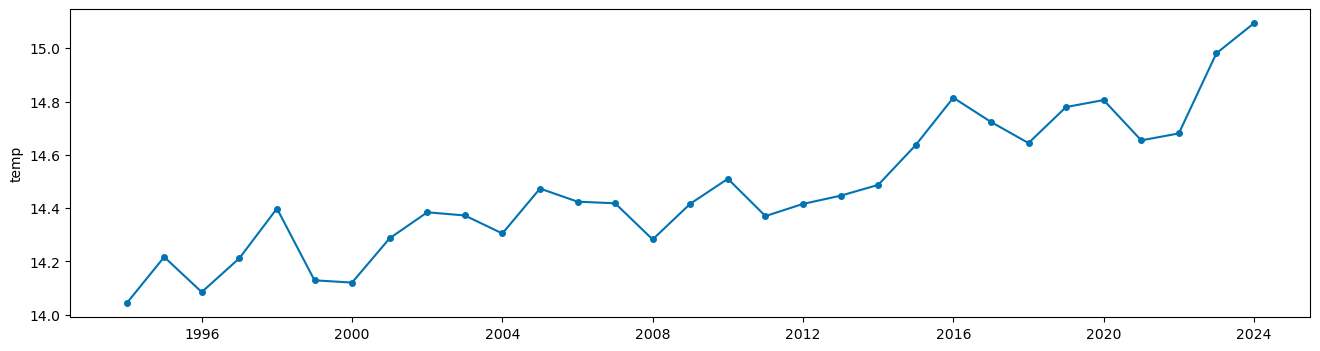

In [4]:
from sktime.utils.plotting import plot_series

plot_series(global_temp)

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='temp'>)

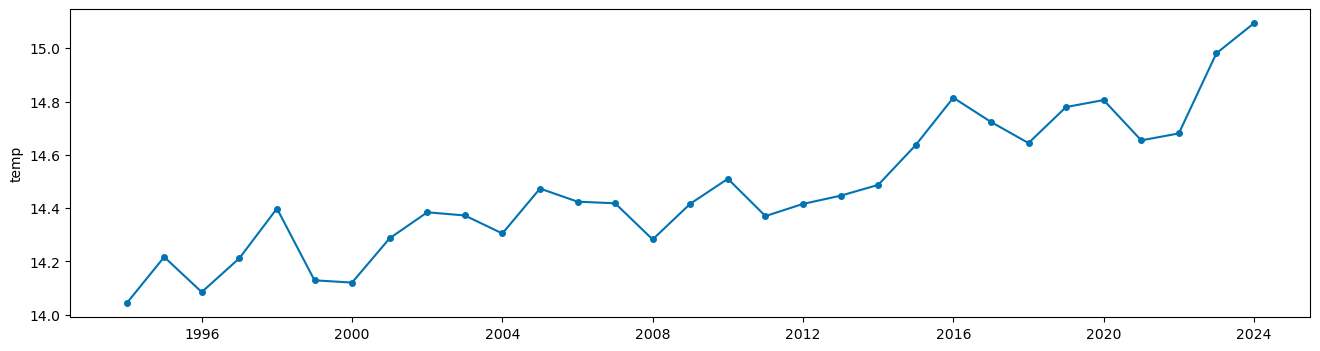

In [5]:
plot_series(global_temp.tail(36))

In [6]:
T = 1
X = []
Y = []

for i in range(0, len(global_temp) - T):
    X.append(global_temp[i:i+T])
    Y.append(global_temp[i+T])

/var/folders/5v/b1rgw4cx4dsdgq25qzpwcwk40000gn/T/ipykernel_24012/943595843.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Y.append(global_temp[i+T])


In [7]:
X = np.array(X).reshape(-1, T, 1)
Y = np.array(Y).reshape(-1, 1)

print("Y=", Y.shape, ", X=", X.shape)

Y= (30, 1) , X= (30, 1, 1)


In [8]:
#from sktime.forecasting.model_selection import temporal_train_test_split
#y_train, y_test = temporal_train_test_split(global_temp, test_size = 10)

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=False)
X_train, X_valid, Y_train, Y_valid = train_test_split(X_train, Y_train, test_size=0.2, shuffle=False)

In [9]:
print("Y_train=", Y_train.shape, ", X_train=", X_train.shape)
print("Y_valid=", Y_valid.shape, ", X_valid=", X_valid.shape)
print("Y_test=", Y_test.shape, ", X_test=", X_test.shape)

Y_train= (19, 1) , X_train= (19, 1, 1)
Y_valid= (5, 1) , X_valid= (5, 1, 1)
Y_test= (6, 1) , X_test= (6, 1, 1)


In [10]:
#print(type(y_test))
#plot_series(y_train, y_test, labels=["y_train", "y_test"])

# 出力数（回帰のため1）
OUT_SIZE = 1
# 隠れ層のユニット数
HIDE_SIZE = 100

In [11]:
#plot_series(y_train.tail(36), y_test, labels=["y_train", "y_test"])

import tensorflow as tf

"""
model = tf.keras.Sequential()

# RNN層
model.add(tf.keras.layers.SimpleRNN(HIDE_SIZE))

# 出力層
model.add(tf.keras.layers.Dense(OUT_SIZE, activation='linear'))

# モデルの構築
model.compile(optimizer = tf.keras.optimizers.Adam(),
              loss='mean_squared_error')

"""
              
model_lstm = tf.keras.Sequential()

# RNN層
model_lstm.add(tf.keras.layers.LSTM(HIDE_SIZE))

# 出力層
model_lstm.add(tf.keras.layers.Dense(OUT_SIZE, activation='linear'))

# モデルの構築
model_lstm.compile(optimizer = tf.keras.optimizers.Adam(),
                   loss='mean_squared_error')

In [12]:
#from sktime.forecasting.arima import AutoARIMA
#model = AutoARIMA(suppress_warnings=True)
#model.fit(y_train)
"""
log = model.fit(X_train, Y_train, epochs=1000, batch_size=32, verbose=True,
                callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                         min_delta=0, patience=100,
                                                         verbose=1)],
                validation_data=(X_valid, Y_valid))
"""

log_lstm = model_lstm.fit(X_train, Y_train, epochs=1000, batch_size=32, verbose=True,
                          callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', 
                                                                      min_delta=0, patience=100, 
                                                                      verbose=1)],
                          validation_data=(X_valid, Y_valid))

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - loss: 190.0272 - val_loss: 197.3990
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 188.5099 - val_loss: 195.8367
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 186.9979 - val_loss: 194.2790
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 185.4904 - val_loss: 192.7246
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 183.9860 - val_loss: 191.1725
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 182.4839 - val_loss: 189.6221
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 180.9835 - val_loss: 188.0730
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 179.4843 - val_loss: 186.5246
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 177.9859 - val_loss: 184.9762
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 176.4875 - val_loss: 183.4274
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 174.9888 - val_loss: 181.8775
Epoch 12/1000
1/1 

In [13]:
#from sktime.forecasting.base import ForecastingHorizon

#fh = ForecastingHorizon(y_test.index, is_relative=False)
#fh

#fh = np.arange(len(y_test))
# 

model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,705 (479.32 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 81,804 (319.55 KB)

Text(0, 0.5, 'crossentropy')

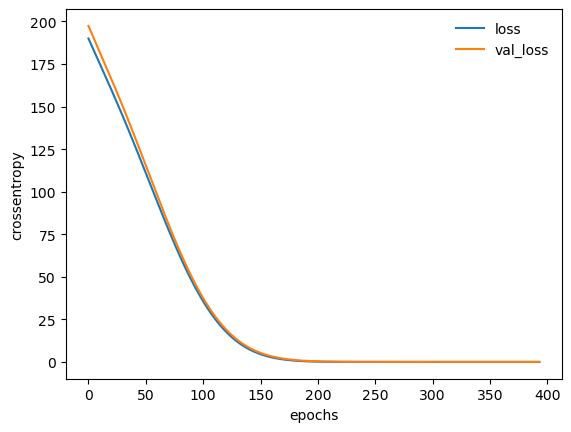

In [14]:
#y_pred = model.predict(fh)
#plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])

plt.plot(log_lstm.history['loss'], label='loss')
plt.plot(log_lstm.history['val_loss'], label='val_loss')
plt.legend(frameon=False) # 凡例の表示
plt.xlabel("epochs")
plt.ylabel("crossentropy")

In [18]:
#plot_series(y_train.tail(24), y_test, y_pred, labels=["y_train", "y_test", "y_pred"])

pred_ys_lstm = model_lstm.predict(X_test)

print(pred_ys_lstm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
[[14.454419]
 [14.50293 ]
 [14.512208]
 [14.458086]
 [14.467456]
 [14.57368 ]]


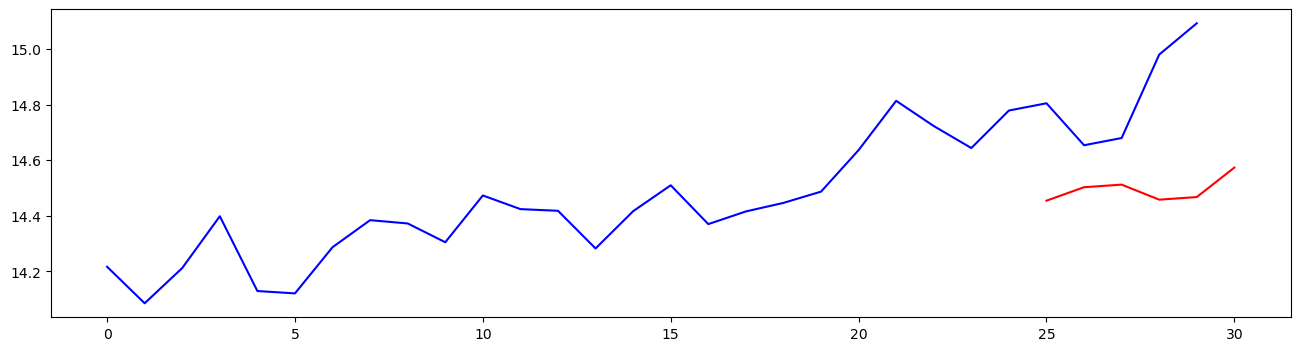

In [16]:
plt.figure(figsize=(16, 4))
plt.plot(range(0, len(X)), Y, color='blue')
plt.plot(range(len(X_train)+len(X_valid)+1, len(X)+1), pred_ys_lstm, color='red')

In [17]:
0.5 * ((Y_test - pred_ys_lstm) ** 2).sum()

0.4001410596895402